Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../OnlineNewsPopularity/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()
df = df.drop(columns=['url', 'timedelta'])

print("Shape:", df.shape)
df.head()

Shape: (39644, 59)


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


Data Types & Memory

In [2]:
print("=" * 50)
print("Dataset Shape:", df.shape)
print("=" * 50)

print("\n--- Data Types ---")
print(df.dtypes.value_counts())

print("\n--- Memory Usage ---")
mem = df.memory_usage(deep=True).sum() / 1e6
print(f"Total Memory: {mem:.2f} MB")

print("\n--- Column Types Detail ---")
print(df.dtypes)

Dataset Shape: (39644, 59)

--- Data Types ---
float64    58
int64       1
Name: count, dtype: int64

--- Memory Usage ---
Total Memory: 18.71 MB

--- Column Types Detail ---
n_tokens_title                   float64
n_tokens_content                 float64
n_unique_tokens                  float64
n_non_stop_words                 float64
n_non_stop_unique_tokens         float64
num_hrefs                        float64
num_self_hrefs                   float64
num_imgs                         float64
num_videos                       float64
average_token_length             float64
num_keywords                     float64
data_channel_is_lifestyle        float64
data_channel_is_entertainment    float64
data_channel_is_bus              float64
data_channel_is_socmed           float64
data_channel_is_tech             float64
data_channel_is_world            float64
kw_min_min                       float64
kw_max_min                       float64
kw_avg_min                       float64
kw_mi

Explored dataset info: shape, data types, and memory usage (18.71 MB).

Missing Values

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


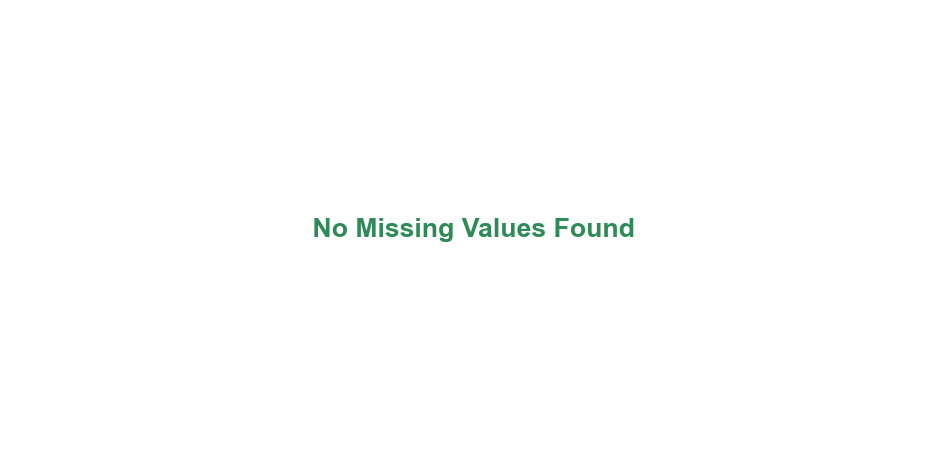

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {missing.sum()}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
if missing.sum() == 0:
    ax.text(0.5, 0.5, ' No Missing Values Found',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=16, color='seagreen', fontweight='bold')
    ax.set_axis_off()
else:
    missing_df[missing_df['Missing Count'] > 0]['Missing %'].plot(
        kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values (%)')
    ax.set_ylabel('Percentage')

plt.tight_layout()
plt.show()

Duplicate Detection

Duplicate rows: 0
Unique rows:    39,644


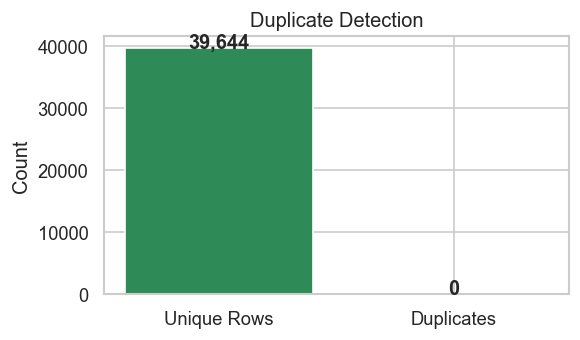

In [4]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print(f"Unique rows:    {len(df) - dupes:,}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Unique Rows', 'Duplicates'],
       [len(df) - dupes, dupes],
       color=['seagreen', 'tomato'], edgecolor='white')
ax.set_title('Duplicate Detection')
ax.set_ylabel('Count')
for i, v in enumerate([len(df) - dupes, dupes]):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

 Target Variable Distribution

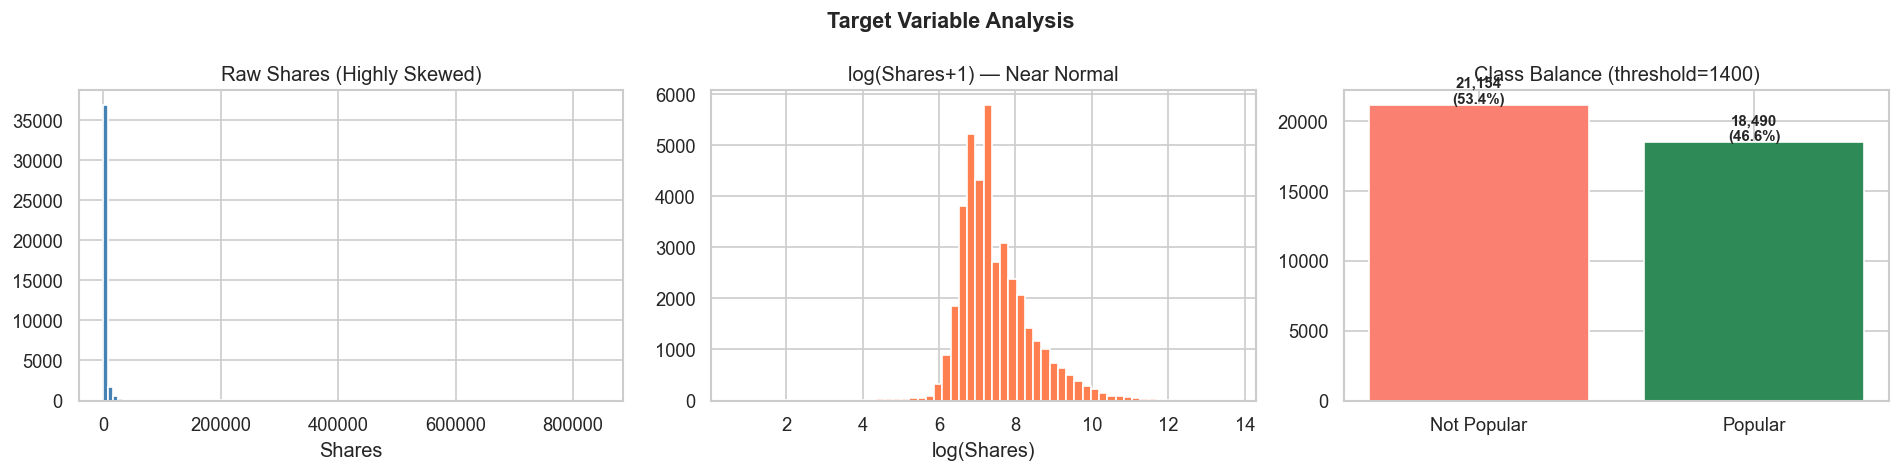

Median: 1400.0 | Mean: 3395 | Skew: 33.96


In [5]:
df['log_shares'] = np.log1p(df['shares'])
median_val = df['shares'].median()
df['popular'] = (df['shares'] >= median_val).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['shares'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Shares (Highly Skewed)')
axes[0].set_xlabel('Shares')

axes[1].hist(df['log_shares'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('log(Shares+1) — Near Normal')
axes[1].set_xlabel('log(Shares)')

counts = df['popular'].value_counts()
axes[2].bar(['Not Popular','Popular'], counts.values,
            color=['salmon','seagreen'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[2].text(i, v+100, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=9)
axes[2].set_title(f'Class Balance (threshold={median_val:.0f})')

plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Median: {median_val} | Mean: {df['shares'].mean():.0f} | Skew: {df['shares'].skew():.2f}")

The target variable `shares` is highly right-skewed (skew = 33.96, median = 1400, mean = 3395), but log-transformation normalizes it well, with a near-balanced class split of 51.1% "Not Popular" vs 48.9% "Popular".

Histograms for All Features

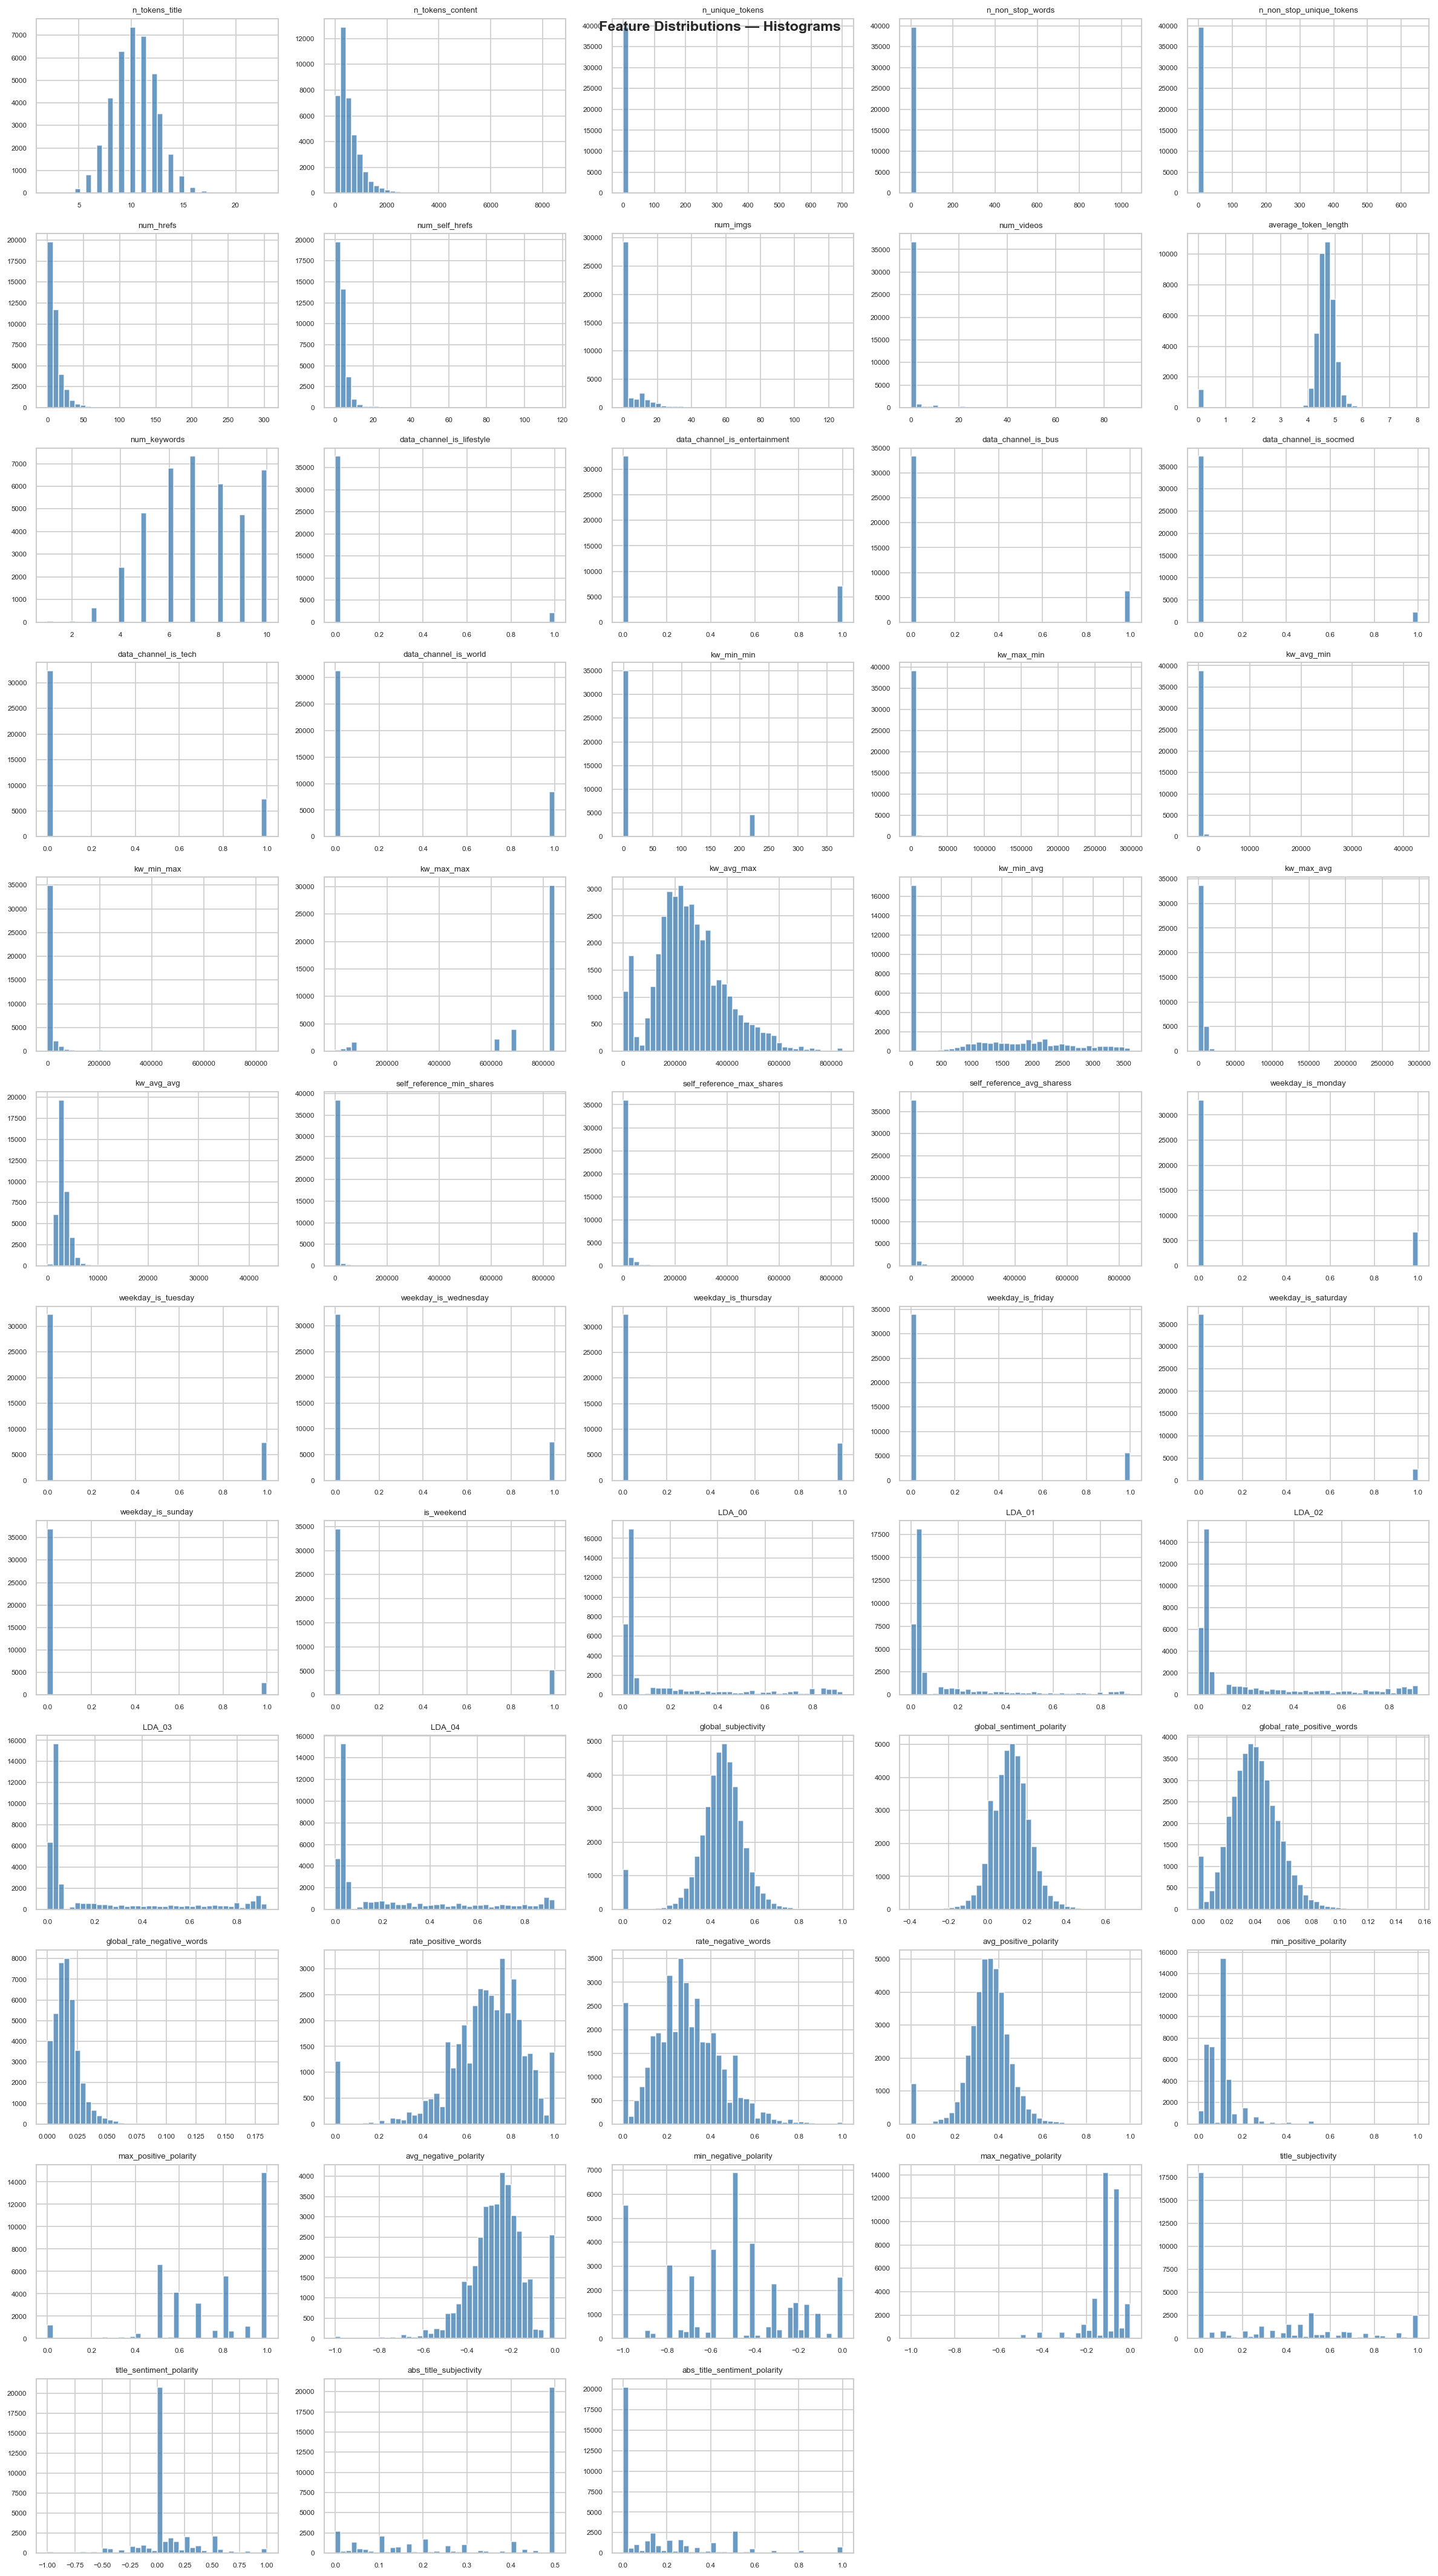

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols
                if c not in ['shares', 'log_shares', 'popular']]

n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Histograms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The histograms show that most features are highly right-skewed with the majority of values concentrated near zero, while a subset of features (particularly NLP/sentiment-related ones) display more bell-shaped, approximately normal distributions.

Density Plots (Top 12 features)

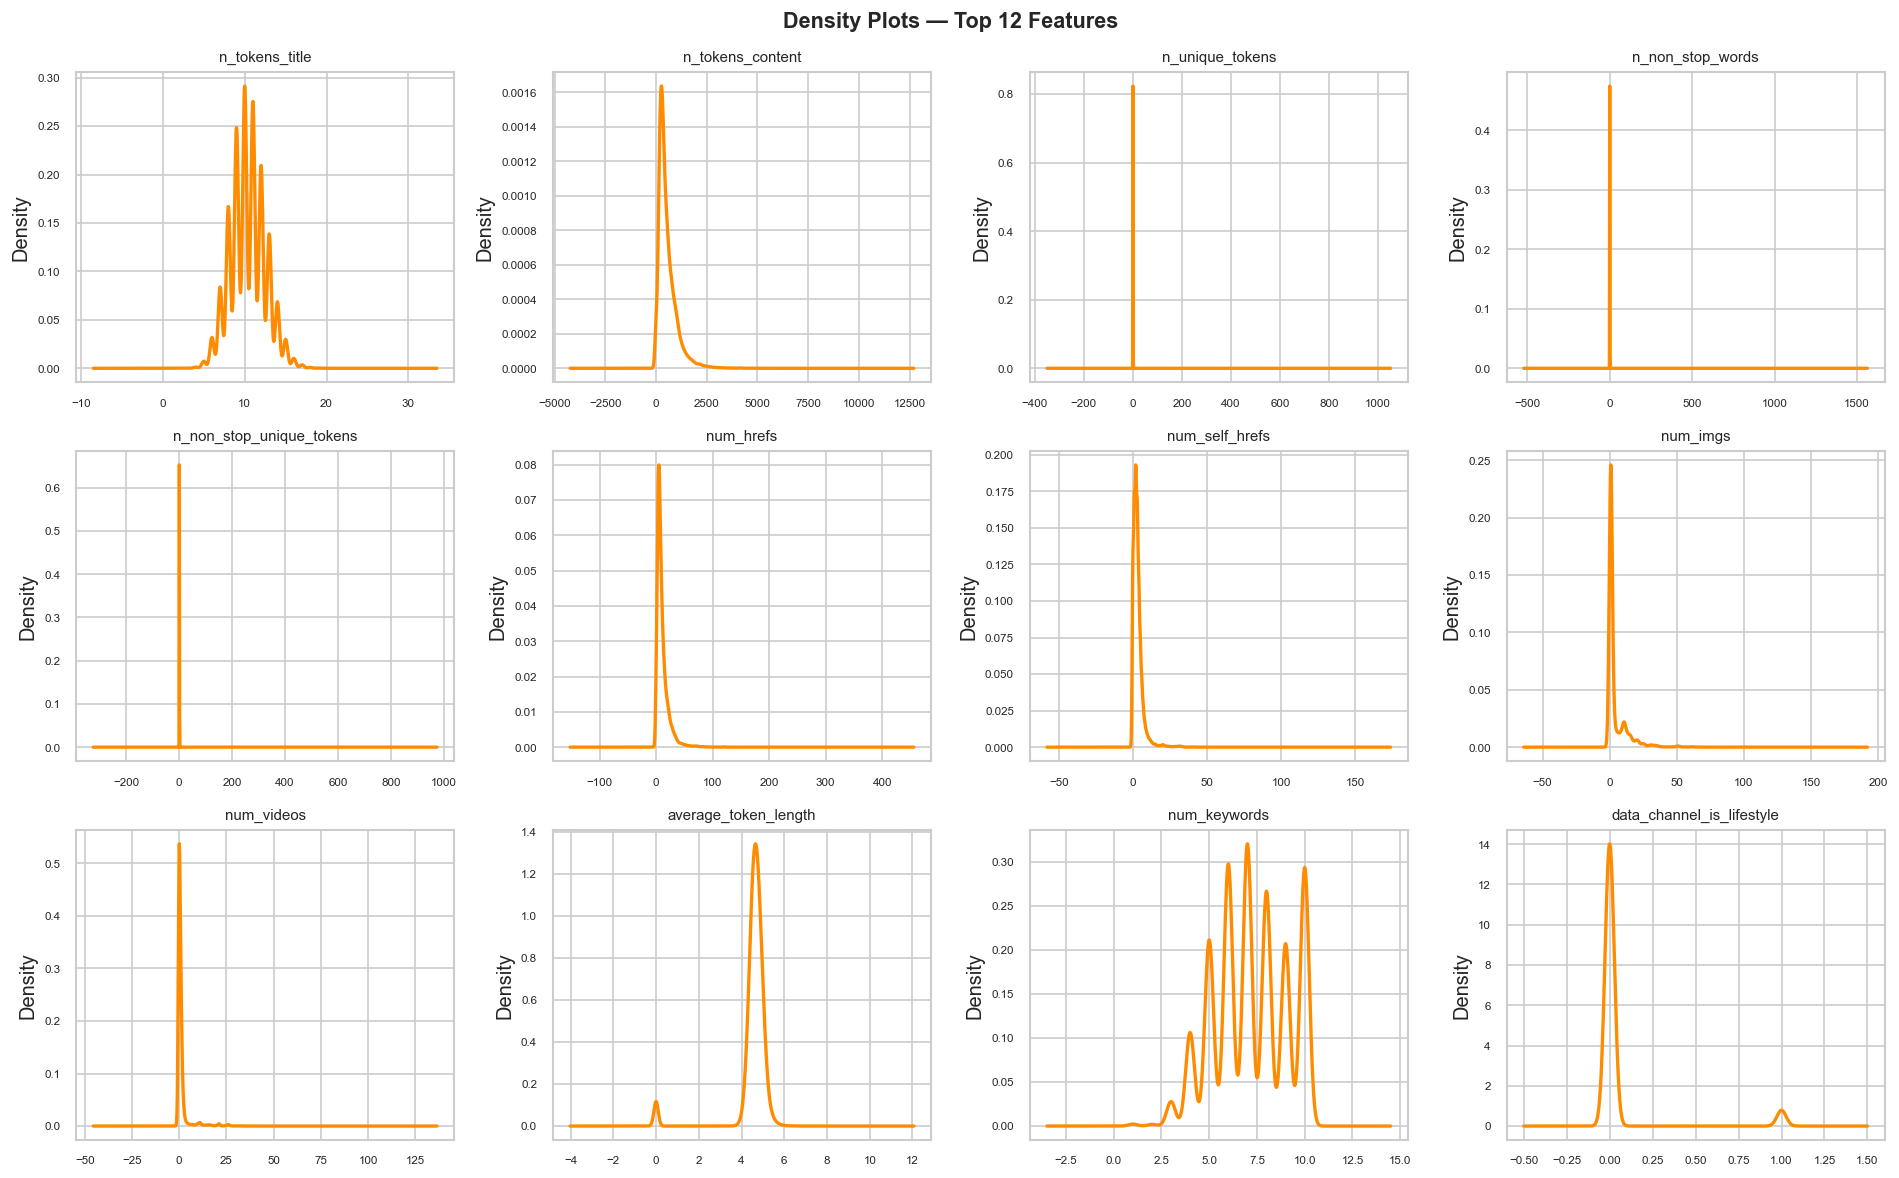

In [7]:
top12 = numeric_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top12):
    df[col].plot(kind='density', ax=axes[i],
                 color='darkorange', linewidth=2)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Density Plots — Top 12 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Density plots for the top 12 numeric features of a dataset

 Boxplots (Outlier Detection Visual)

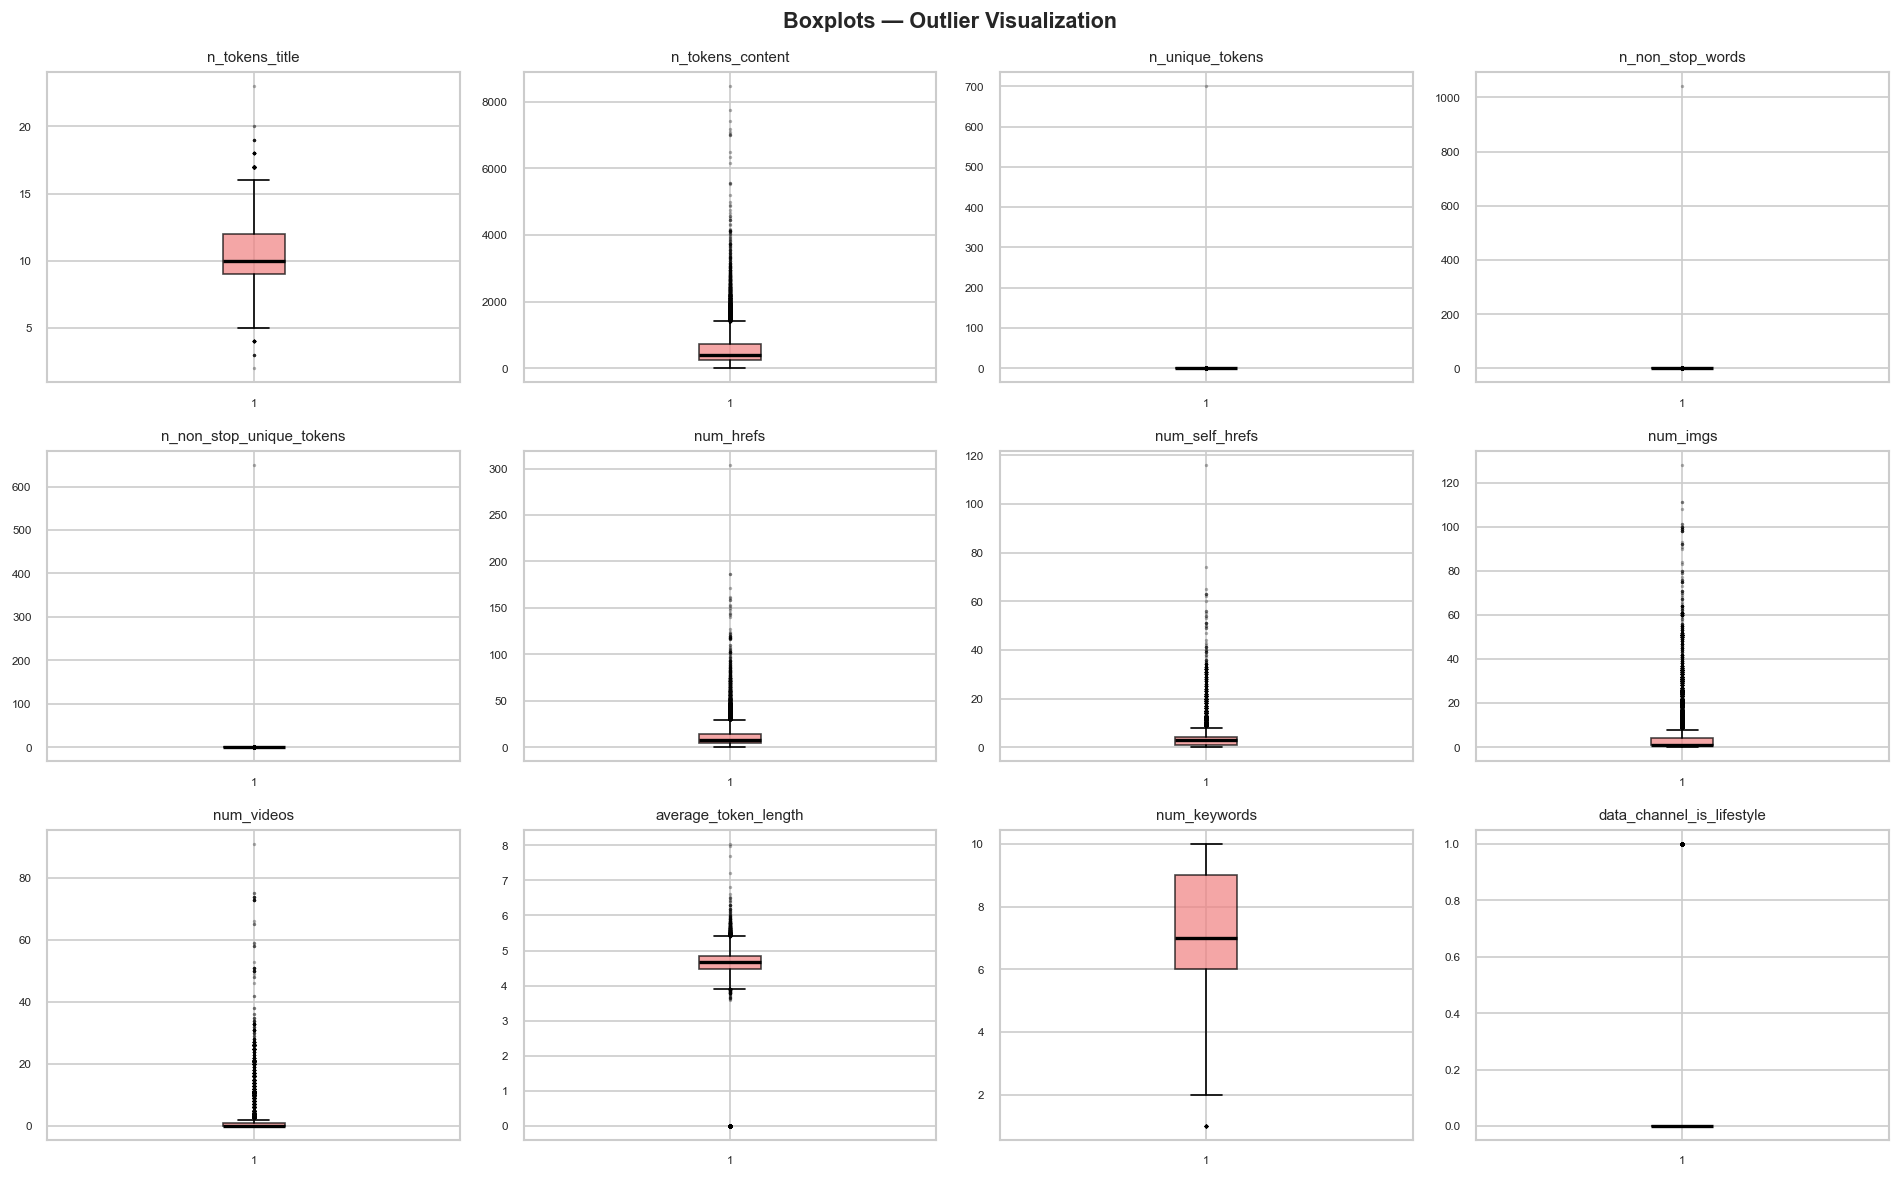

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top12):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Boxplots — Outlier Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Most features show heavy right-skewed distributions with extreme outliers, indicating that the data would benefit from log transformation or outlier capping before modeling.

Correlation Heatmap

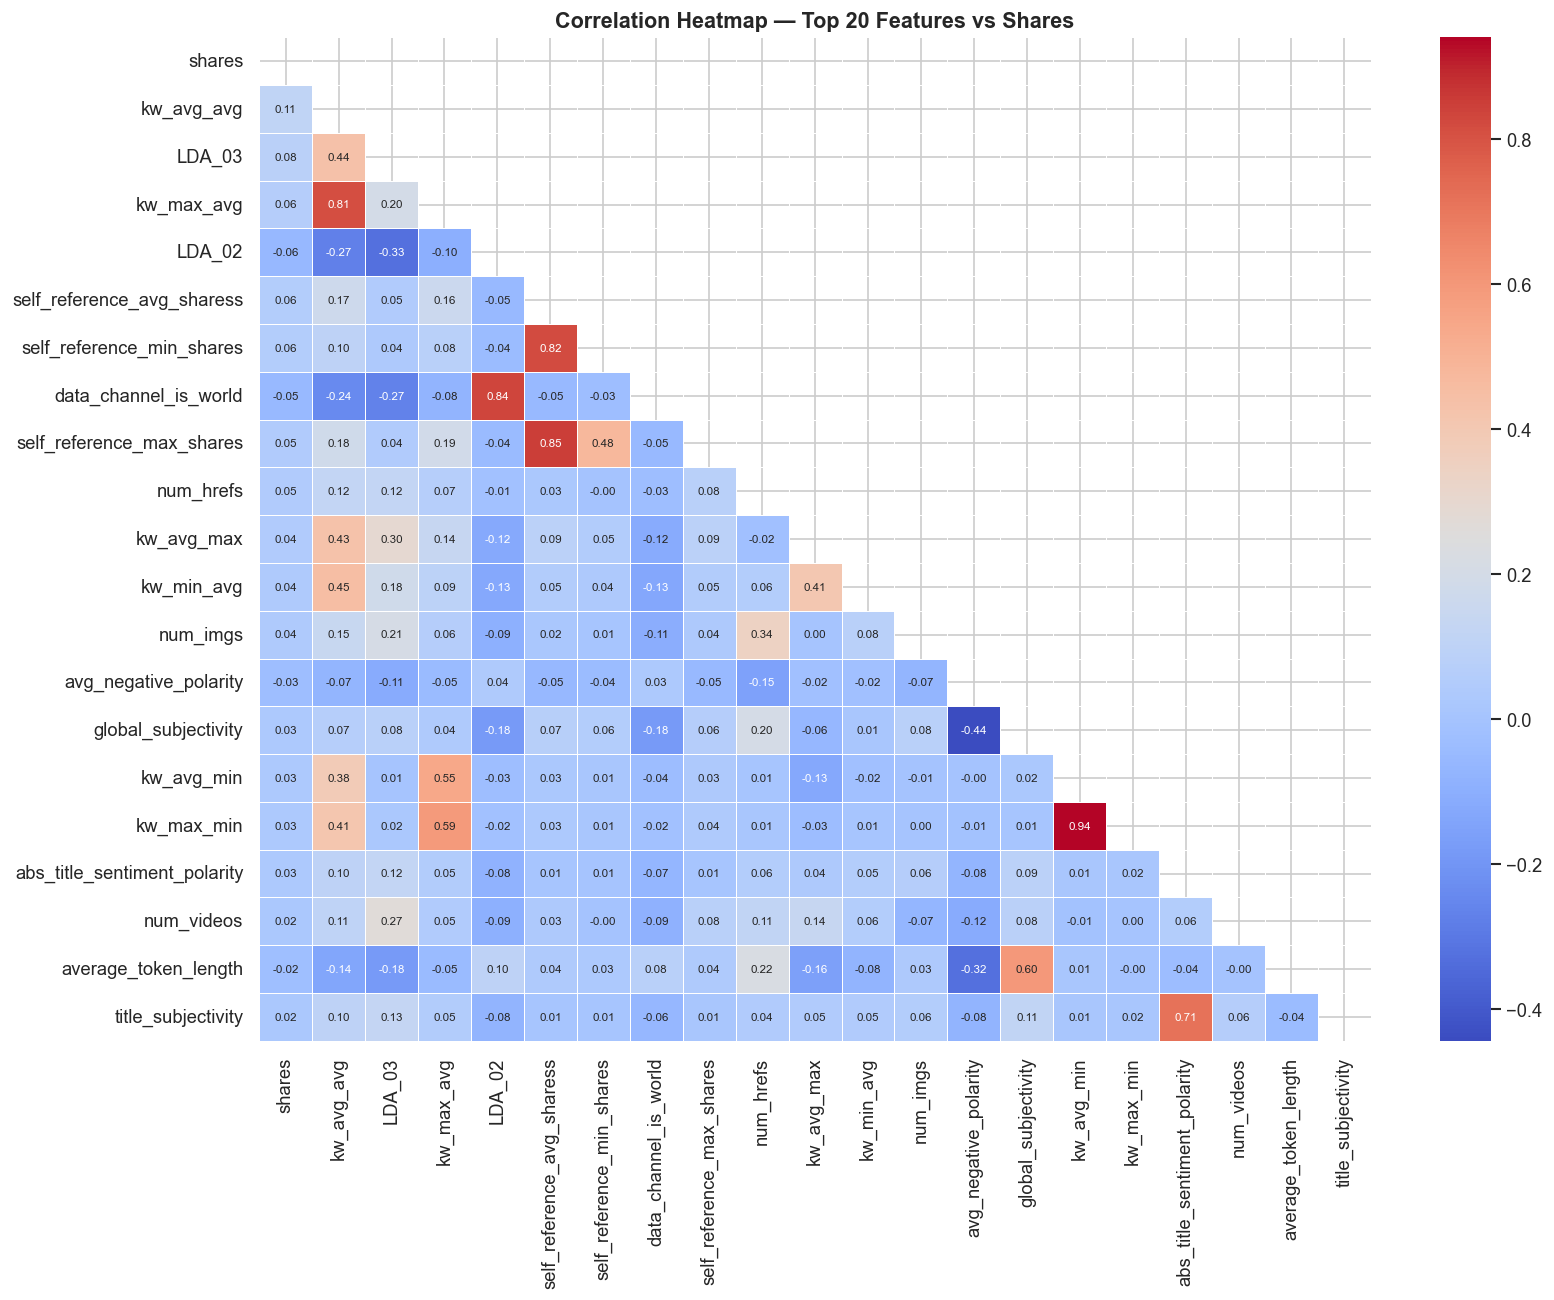

In [9]:
top_corr_cols = (df[numeric_cols + ['shares']]
                 .corr()['shares']
                 .abs()
                 .sort_values(ascending=False)
                 .head(21)
                 .index.tolist())

corr_matrix = df[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Top 20 Features vs Shares',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap reveals mostly weak correlations with shares, with `kw_avg_avg` being the strongest (r = 0.11), while keyword-related features show moderate inter-correlations (e.g., `kw_max_avg` vs `kw_min_avg` at 0.41).

Scatter Plots (Top 6 vs shares)

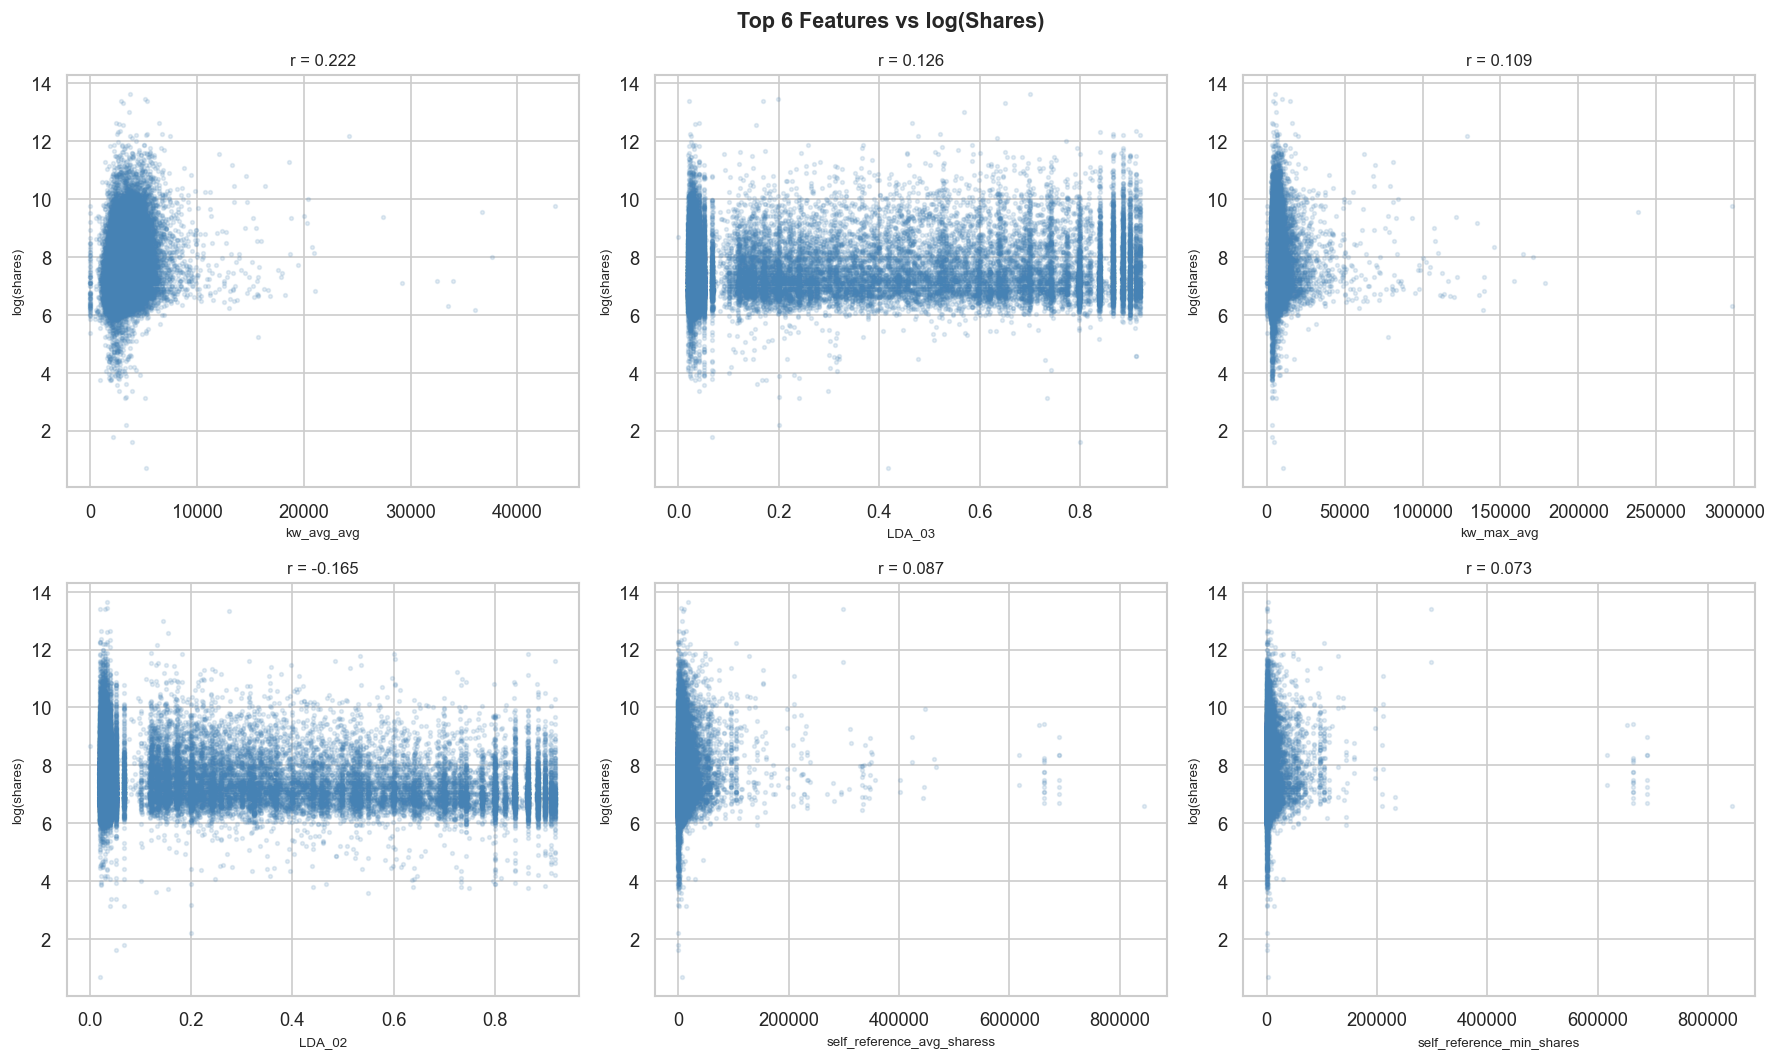

In [10]:
top6 = (df[numeric_cols].corrwith(df['shares'])
        .abs().sort_values(ascending=False).head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(top6):
    axes[i].scatter(df[col], df['log_shares'],
                    alpha=0.15, s=5, color='steelblue')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('log(shares)', fontsize=8)
    r, p = stats.pearsonr(df[col], df['log_shares'])
    axes[i].set_title(f'r = {r:.3f}', fontsize=10)

plt.suptitle('Top 6 Features vs log(Shares)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Plotted scatter plots for the top 6 features most correlated with log(shares), showing weak positive correlations (highest r = 0.222 for kw_avg_avg), indicating no single feature strongly predicts shares.

Day of Week Analysis

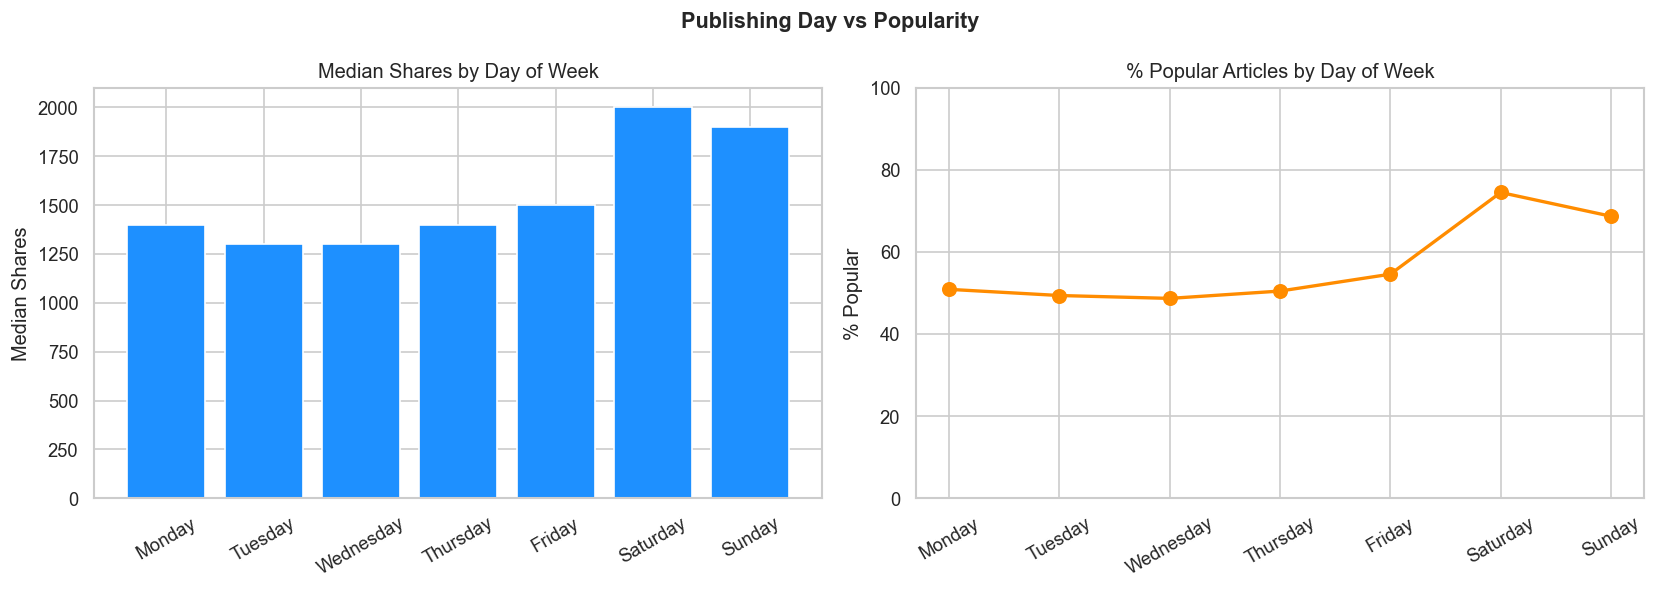

In [11]:
day_cols  = [c for c in df.columns if 'weekday_is' in c]
day_names = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_medians = [df[df[col]==1]['shares'].median() for col in day_cols]
day_pop_pct = [df[df[col]==1]['popular'].mean()*100 for col in day_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_names, day_medians, color='dodgerblue', edgecolor='white')
axes[0].set_title('Median Shares by Day of Week')
axes[0].set_ylabel('Median Shares')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(day_names, day_pop_pct, marker='o',
             color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('% Popular Articles by Day of Week')
axes[1].set_ylabel('% Popular')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 100)

plt.suptitle('Publishing Day vs Popularity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Saturday is the best day to publish — it delivers the highest median shares (~1,900) and the greatest chance of going viral (~70% popular articles), with Sunday close behind, while weekdays consistently underperform on both metrics.

Channel Analysis

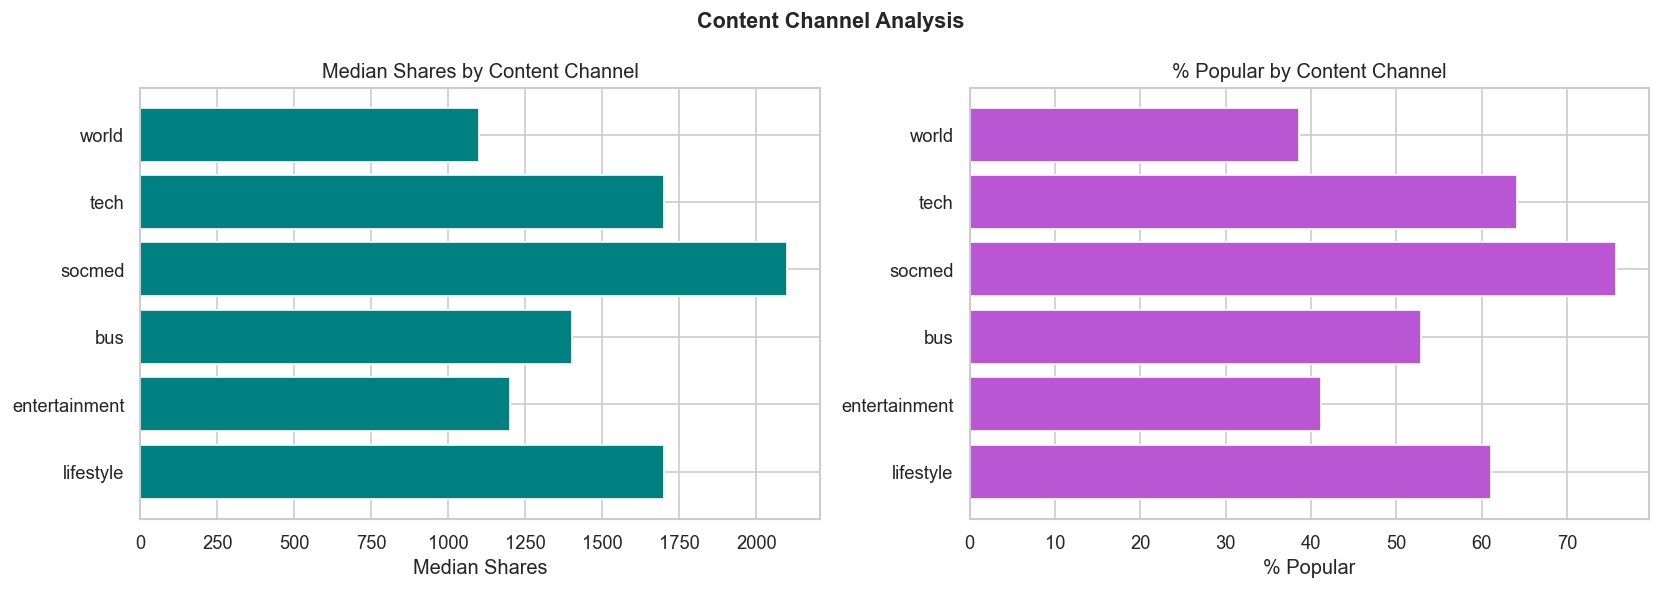

In [12]:
channel_cols = [c for c in df.columns if 'data_channel_is' in c]
channel_names = [c.replace('data_channel_is_','') for c in channel_cols]

ch_median = [df[df[col]==1]['shares'].median() for col in channel_cols]
ch_pop    = [df[df[col]==1]['popular'].mean()*100 for col in channel_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(channel_names, ch_median, color='teal', edgecolor='white')
axes[0].set_title('Median Shares by Content Channel')
axes[0].set_xlabel('Median Shares')

axes[1].barh(channel_names, ch_pop, color='mediumorchid', edgecolor='white')
axes[1].set_title('% Popular by Content Channel')
axes[1].set_xlabel('% Popular')

plt.suptitle('Content Channel Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Social media (socmed) and tech channels lead in both median shares (~1750–2000) and popularity rate (~65–70%), while entertainment and world channels perform the lowest across both metrics.

Sentiment vs Shares

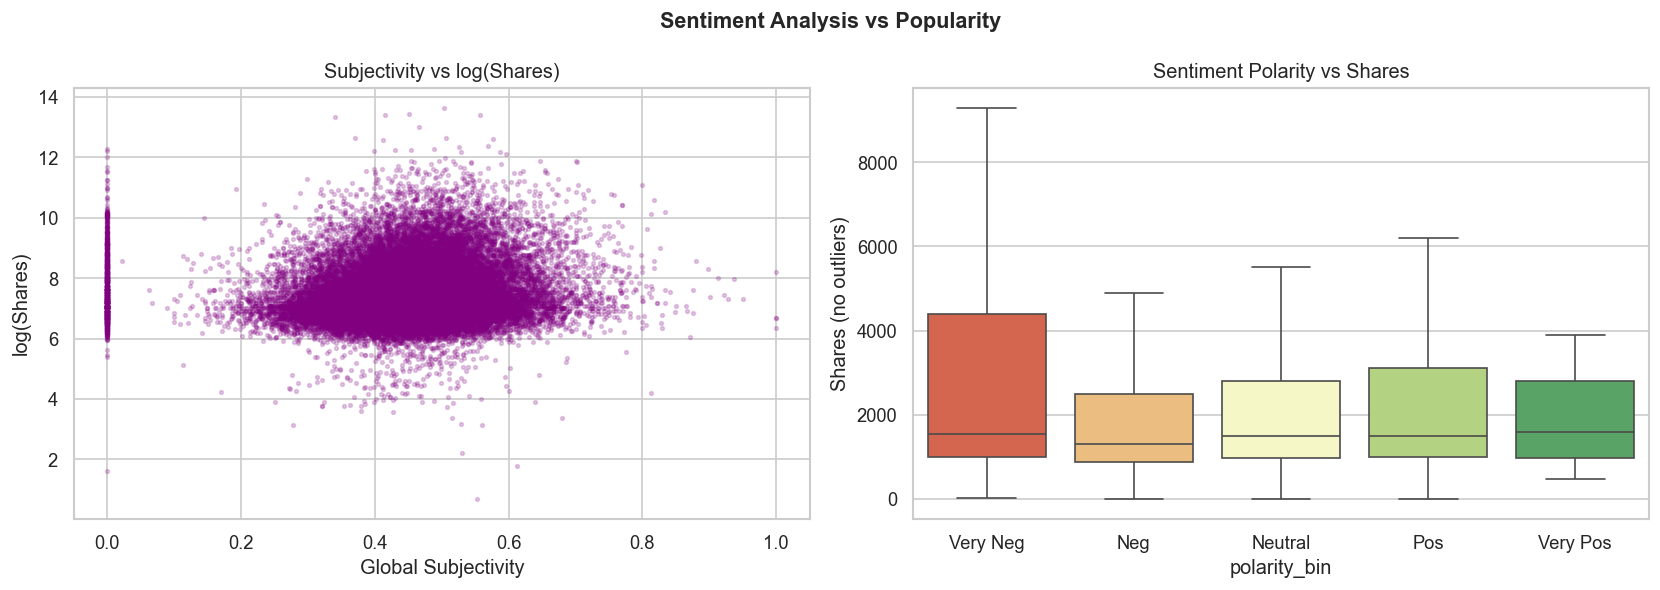

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['global_subjectivity'], df['log_shares'],
                alpha=0.2, s=5, color='purple')
axes[0].set_xlabel('Global Subjectivity')
axes[0].set_ylabel('log(Shares)')
axes[0].set_title('Subjectivity vs log(Shares)')

df['polarity_bin'] = pd.cut(
    df['global_sentiment_polarity'], bins=5,
    labels=['Very Neg','Neg','Neutral','Pos','Very Pos'])

sns.boxplot(x='polarity_bin', y='shares', data=df,
            ax=axes[1], palette='RdYlGn', showfliers=False)
axes[1].set_title('Sentiment Polarity vs Shares')
axes[1].set_ylabel('Shares (no outliers)')

plt.suptitle('Sentiment Analysis vs Popularity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Global subjectivity shows no clear relationship with log(shares), and sentiment polarity has minimal impact on share counts, with median shares remaining relatively stable (~2000) across all polarity bins from very negative to very positive.

 Impossible Values Detection

                       Count  Percentage
n_tokens_content == 0   1181        2.98
n_unique_tokens > 1        1        0.00
n_non_stop_words > 1       1        0.00
num_imgs < 0               0        0.00
num_videos < 0             0        0.00
shares <= 0                0        0.00


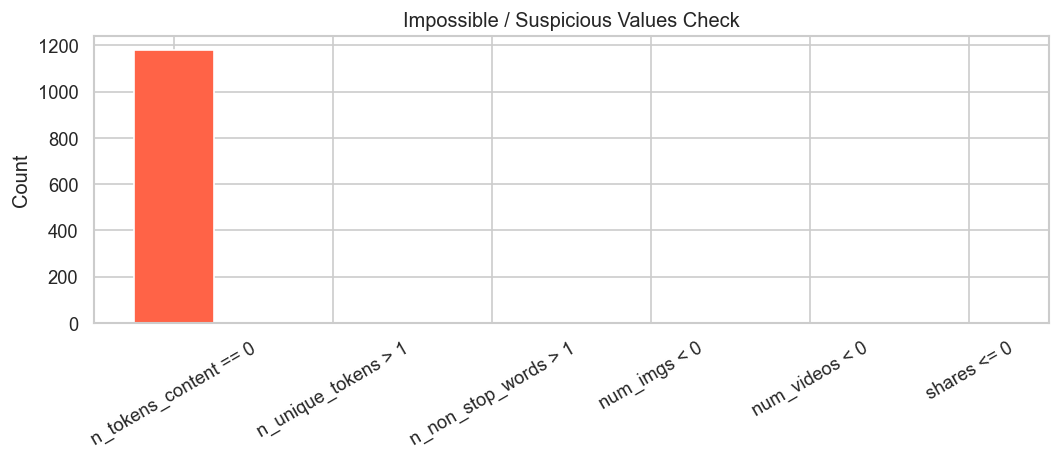

In [14]:

checks = {
    'n_tokens_content == 0':     (df['n_tokens_content'] == 0).sum(),
    'n_unique_tokens > 1':       (df['n_unique_tokens'] > 1).sum(),
    'n_non_stop_words > 1':      (df['n_non_stop_words'] > 1).sum(),
    'num_imgs < 0':              (df['num_imgs'] < 0).sum(),
    'num_videos < 0':            (df['num_videos'] < 0).sum(),
    'shares <= 0':               (df['shares'] <= 0).sum(),
}

check_df = pd.DataFrame.from_dict(checks, orient='index',
                                   columns=['Count'])
check_df['Percentage'] = (check_df['Count'] / len(df) * 100).round(2)
print(check_df)

fig, ax = plt.subplots(figsize=(9, 4))
check_df['Count'].plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Impossible / Suspicious Values Check')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

The only data quality issue found is that 1,181 articles (2.98%) have zero content tokens, indicating empty articles, while all other suspicious value checks came back completely clean.

Handle Suspicious Values

Rows before:  39,644
Rows removed: 1,182
Rows after:   38,462

n_unique_tokens  max: 1.0000
n_non_stop_words max: 1.0000


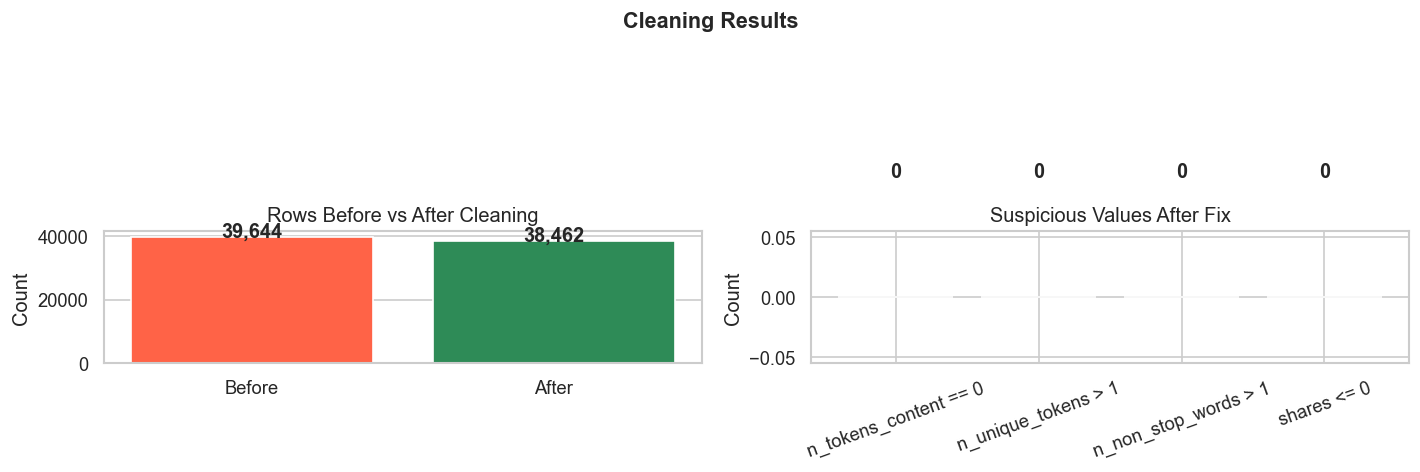


 All suspicious values handled!
Final shape: (38462, 62)


In [15]:


before = len(df)

mask = (
    (df['n_tokens_content'] > 0)  &
    (df['n_unique_tokens']  <=  1 ) &
    (df['n_non_stop_words'] <=  1 )
)
df = df[mask].copy()



after = len(df)

print(f"Rows before:  {before:,}")
print(f"Rows removed: {before - after:,}")
print(f"Rows after:   {after:,}")
print(f"\nn_unique_tokens  max: {df['n_unique_tokens'].max():.4f}")
print(f"n_non_stop_words max: {df['n_non_stop_words'].max():.4f}")


df['log_shares'] = np.log1p(df['shares'])
df['popular']    = (df['shares'] >= df['shares'].median()).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Before', 'After'],
            [before, after],
            color=['tomato', 'seagreen'], edgecolor='white')
axes[0].set_title('Rows Before vs After Cleaning')
axes[0].set_ylabel('Count')
for i, v in enumerate([before, after]):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

checks_after = {
    'n_tokens_content == 0': (df['n_tokens_content'] == 0).sum(),
    'n_unique_tokens > 1':   (df['n_unique_tokens'] > 1).sum(),
    'n_non_stop_words > 1':  (df['n_non_stop_words'] > 1).sum(),
    'shares <= 0':           (df['shares'] <= 0).sum(),
}
axes[1].bar(checks_after.keys(), checks_after.values(),
            color='steelblue', edgecolor='white')
axes[1].set_title('Suspicious Values After Fix')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(checks_after.values()):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Cleaning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n All suspicious values handled!")
print(f"Final shape: {df.shape}")

After removing 1,182 invalid rows (empty content and suspicious token values), the dataset was cleaned from 39,644 down to 38,462 rows with 62 features, and all remaining suspicious value checks returned zero issues.

Outlier Detection (IQR)

                   feature  n_outliers   pct
                kw_max_max        9365 24.35
  title_sentiment_polarity        7918 20.59
                  num_imgs        7465 19.41
                    LDA_01        5682 14.77
                    LDA_00        5071 13.18
 self_reference_min_shares        4884 12.70
                kw_min_max        4826 12.55
                kw_min_min        4638 12.06
self_reference_avg_sharess        4175 10.85
 self_reference_max_shares        4094 10.64
                kw_max_min        3566  9.27
                    LDA_02        3441  8.95
     min_positive_polarity        3147  8.18
                    LDA_03        3028  7.87
                num_videos        2939  7.64


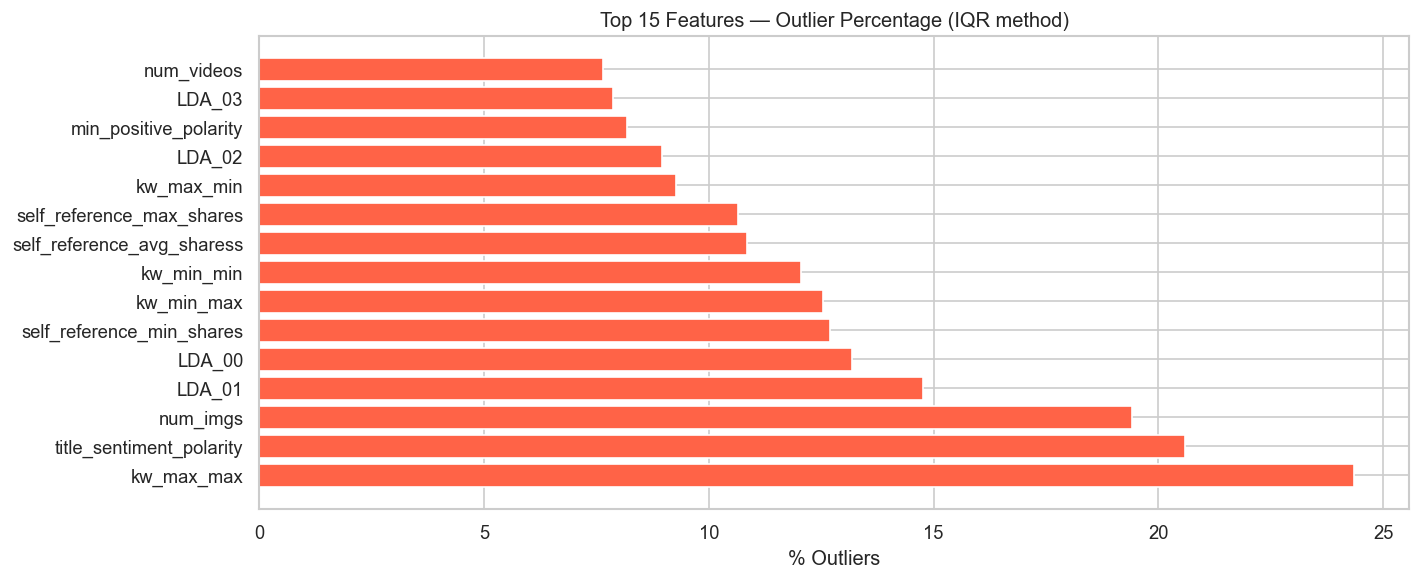

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols
                if c not in ['shares','log_shares','popular','polarity_bin']
                and df[c].nunique() > 2]

outlier_report = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report.append({
        'feature': col,
        'n_outliers': n_out,
        'pct': round(n_out / len(df) * 100, 2)
    })

outlier_df = (pd.DataFrame(outlier_report)
                .sort_values('pct', ascending=False))

print(outlier_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
top15 = outlier_df.head(15)
ax.barh(top15['feature'], top15['pct'],
        color='tomato', edgecolor='white')
ax.set_title('Top 15 Features — Outlier Percentage (IQR method)')
ax.set_xlabel('% Outliers')
plt.tight_layout()
plt.show()


The IQR outlier detection reveals that **kw_max_max** has the highest outlier rate at 24.35%, followed by **title_sentiment_polarity** (20.59%) and **num_imgs** (19.41%), indicating that keyword-based and sentiment features contain the most extreme values and will likely require capping or transformation before modeling.

Winsorization vs Removal Comparison

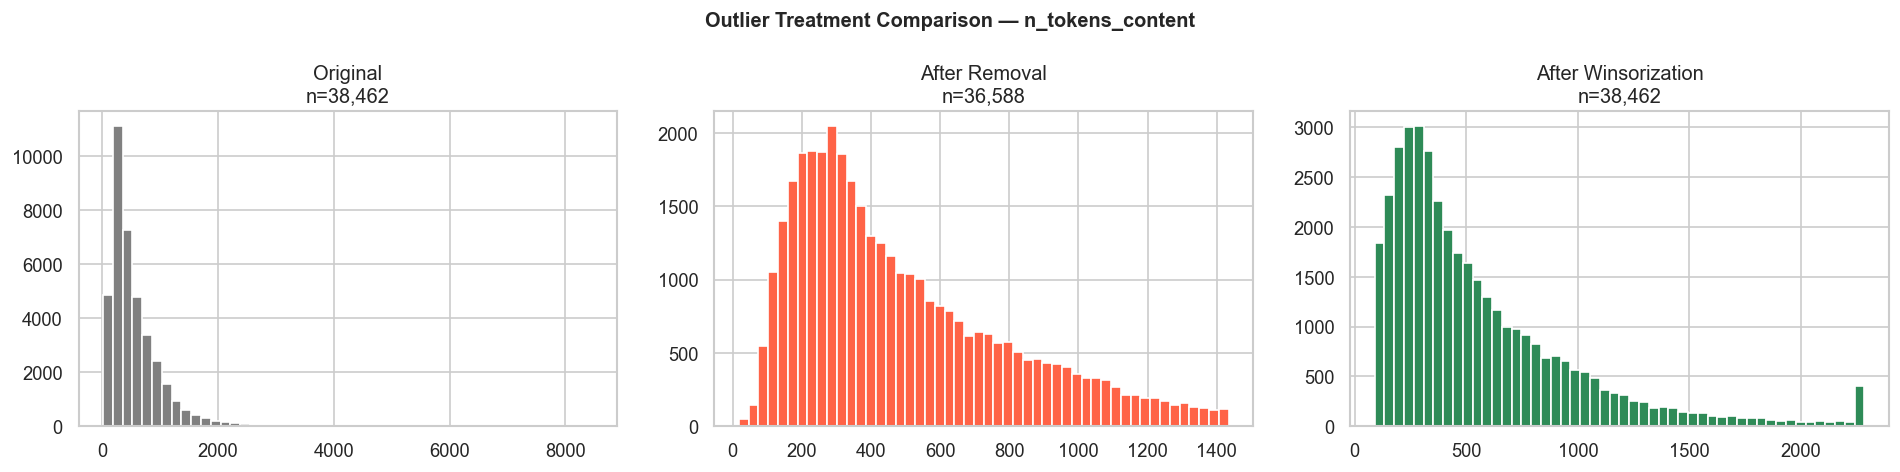

Original rows:     38,462
After removal:     36,588 (lost 1,874 rows)
After winsorize:   38,462 (lost 0 rows)


In [17]:
col_test = 'n_tokens_content'  


Q1 = df[col_test].quantile(0.25)
Q3 = df[col_test].quantile(0.75)
IQR = Q3 - Q1
df_removed = df[(df[col_test] >= Q1-1.5*IQR) &
                (df[col_test] <= Q3+1.5*IQR)]


df_winsorized = df.copy()
df_winsorized[col_test] = df_winsorized[col_test].clip(
    df_winsorized[col_test].quantile(0.01),
    df_winsorized[col_test].quantile(0.99))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df[col_test], bins=50, color='gray', edgecolor='w')
axes[0].set_title(f'Original\nn={len(df):,}')

axes[1].hist(df_removed[col_test], bins=50, color='tomato', edgecolor='w')
axes[1].set_title(f'After Removal\nn={len(df_removed):,}')

axes[2].hist(df_winsorized[col_test], bins=50, color='seagreen', edgecolor='w')
axes[2].set_title(f'After Winsorization\nn={len(df_winsorized):,}')

plt.suptitle(f'Outlier Treatment Comparison — {col_test}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original rows:     {len(df):,}")
print(f"After removal:     {len(df_removed):,} (lost {len(df)-len(df_removed):,} rows)")
print(f"After winsorize:   {len(df_winsorized):,} (lost 0 rows)")

Outlier removal on `n_tokens_content` eliminated 1,874 rows (dropping from 38,462 to 36,588) and produced a cleaner right-skewed distribution, while winsorization retained all rows by capping extremes at the 1st and 99th percentiles instead of discarding them — making winsorization the less data-wasteful approach for handling outliers in this feature.

Apply Winsorization to All Features

 Winsorization applied to all numeric features
Shape before: (38462, 62)
Shape after:  (38462, 62)


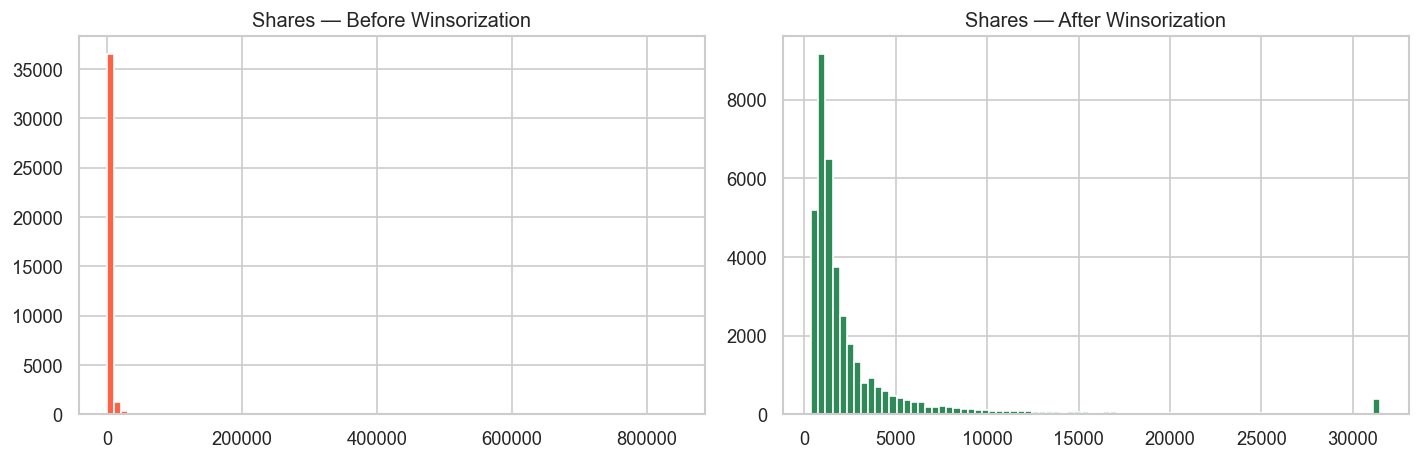

In [18]:
df_clean = df.copy()

for col in numeric_cols + ['shares']:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

print(" Winsorization applied to all numeric features")
print("Shape before:", df.shape)
print("Shape after: ", df_clean.shape)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['shares'], bins=80, color='tomato', edgecolor='w')
axes[0].set_title('Shares — Before Winsorization')
axes[1].hist(df_clean['shares'], bins=80, color='seagreen', edgecolor='w')
axes[1].set_title('Shares — After Winsorization')
plt.tight_layout()
plt.show()

Winsorization clipped extreme outliers in the shares column (at the 1st and 99th percentiles) without changing the dataset size (38,462 × 62), compressing the x-axis from ~800,000 down to ~30,000 and revealing a clearer right-skewed distribution where most articles receive under 5,000 shares.

Outlier Detection

Binary columns (skipped):        15
Continuous columns (winsorized): 44

Shares max before: 843,300
Shares max after:  31,500.0


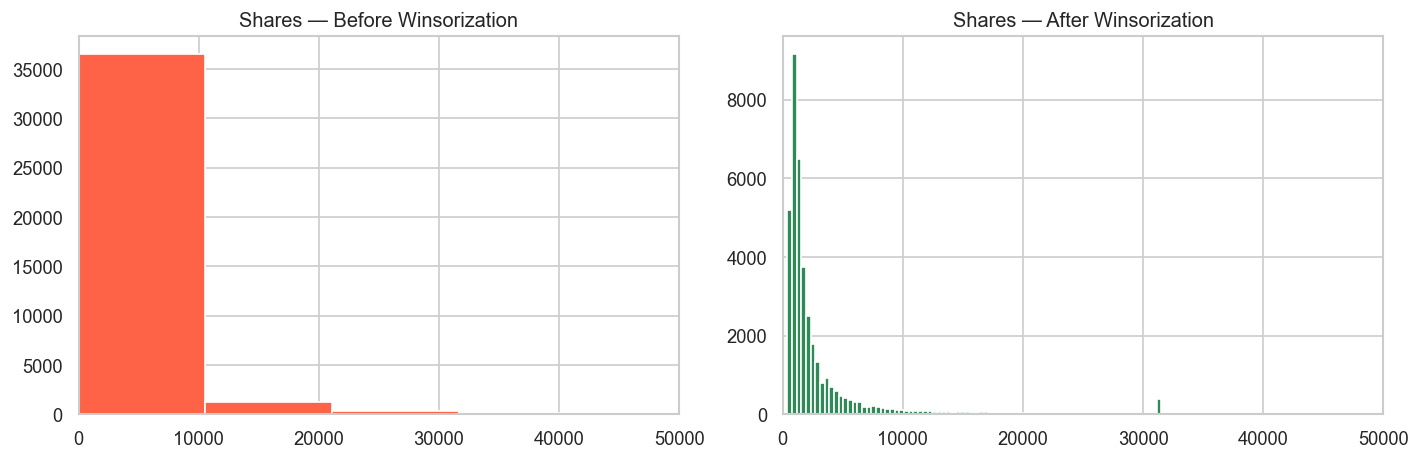

In [19]:
all_numeric = df.select_dtypes(include=np.number).columns.tolist()
binary_cols = [c for c in all_numeric if df[c].nunique() == 2]
continuous_cols = [c for c in all_numeric 
                   if c not in binary_cols 
                   and c not in ['shares','log_shares','popular','polarity_bin']]


print(f"Binary columns (skipped):        {len(binary_cols)}")
print(f"Continuous columns (winsorized): {len(continuous_cols)}")


df_clean = df.copy()
for col in continuous_cols + ['shares']:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

print(f"\nShares max before: {df['shares'].max():,}")
print(f"Shares max after:  {df_clean['shares'].max():,}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['shares'], bins=80, color='tomato', edgecolor='w')
axes[0].set_title('Shares — Before Winsorization')
axes[0].set_xlim(0, 50000)

axes[1].hist(df_clean['shares'], bins=80, color='seagreen', edgecolor='w')
axes[1].set_title('Shares — After Winsorization')
axes[1].set_xlim(0, 50000)

plt.tight_layout()
plt.show()


The outlier detection step skipped 15 binary columns and winsorized 44 continuous ones, slashing the maximum shares value from 843,300 down to 31,500 — effectively removing extreme outliers and making the distribution far more interpretable for modeling.

Scaler Comparison

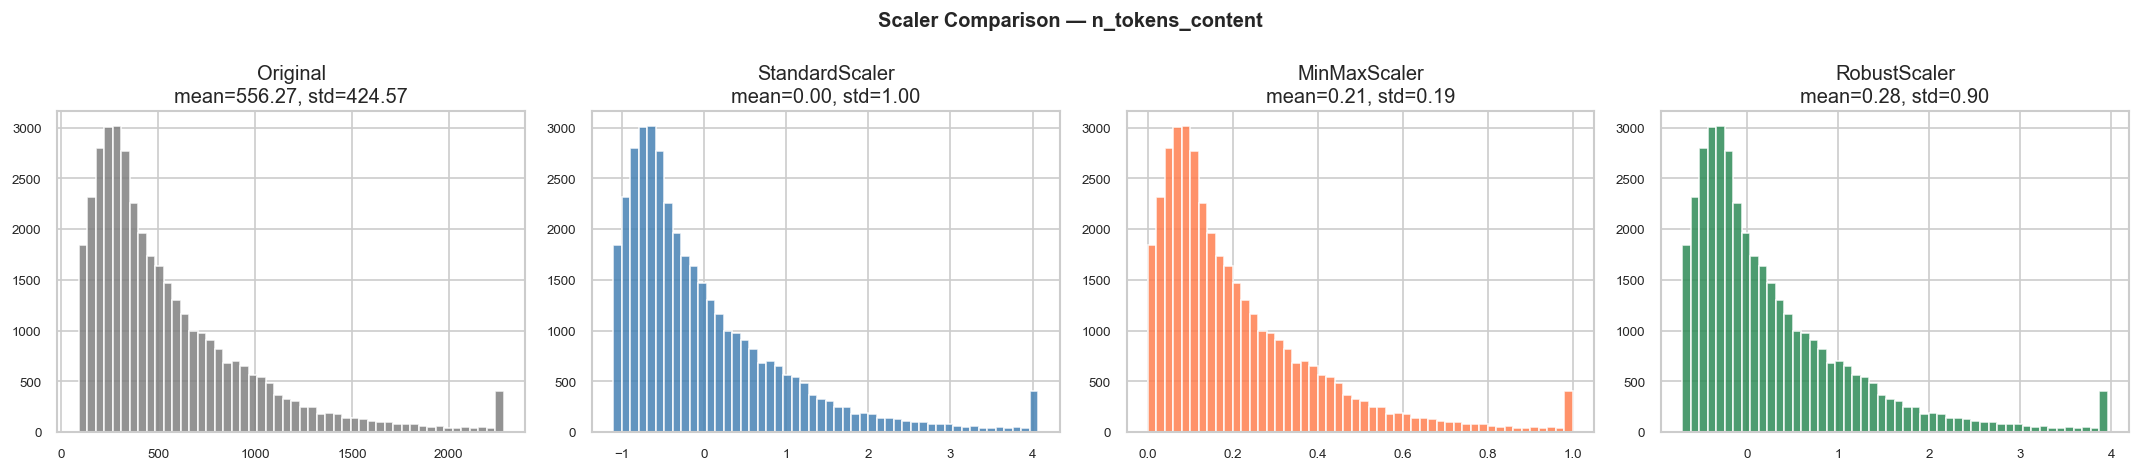

In [20]:
sample_col = 'n_tokens_content'
scalers = {
    'Original':      df_clean[sample_col].values,
    'StandardScaler': StandardScaler().fit_transform(
                        df_clean[[sample_col]]).flatten(),
    'MinMaxScaler':   MinMaxScaler().fit_transform(
                        df_clean[[sample_col]]).flatten(),
    'RobustScaler':   RobustScaler().fit_transform(
                        df_clean[[sample_col]]).flatten()
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['gray','steelblue','coral','seagreen']

for ax, (name, data), color in zip(axes, scalers.items(), colors):
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}\nmean={data.mean():.2f}, std={data.std():.2f}')
    ax.tick_params(labelsize=8)

plt.suptitle(f'Scaler Comparison — {sample_col}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

All four scalers preserve the same right-skewed shape of `n_tokens_content` (original mean≈556, std≈425), with StandardScaler centering at 0, MinMaxScaler compressing to [0,1], and RobustScaler producing similar rescaling — confirming the skewness is a data characteristic, not a scaling artifact.

Scaling Decision Summary

              Model Needs Scaling Recommended Scaler
Logistic Regression           Yes     StandardScaler
                SVM           Yes     StandardScaler
                KNN           Yes       RobustScaler
      Decision Tree            No               None
      Random Forest            No               None
            XGBoost            No               None


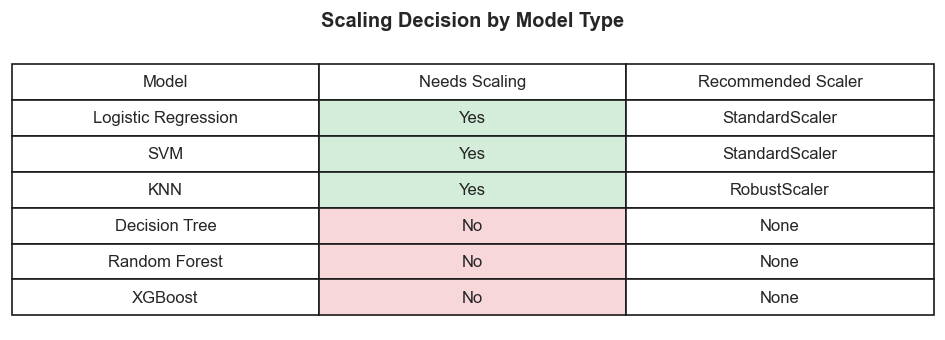

In [21]:
scaling_decision = {
    'Model': ['Logistic Regression', 'SVM', 'KNN',
              'Decision Tree', 'Random Forest', 'XGBoost'],
    'Needs Scaling': ['Yes', 'Yes', 'Yes', 'No', 'No', 'No'],
    'Recommended Scaler': ['StandardScaler', 'StandardScaler', 'RobustScaler',
                            'None', 'None', 'None']
}

decision_df = pd.DataFrame(scaling_decision)
print(decision_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table = ax.table(cellText=decision_df.values,
                 colLabels=decision_df.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

for i in range(1, 4):
    cell = table[i, 1]
    cell.set_facecolor('#d4edda')

for i in range(4, 7):
    cell = table[i, 1]
    cell.set_facecolor('#f8d7da')

plt.title('Scaling Decision by Model Type', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/p17_scaling_decision.png', bbox_inches='tight')
plt.show()

Categorical Variables Check

Binary (0/1) columns found: 15
['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'popular']

Object/String columns: []
→ No encoding needed (all categoricals already binary-encoded)


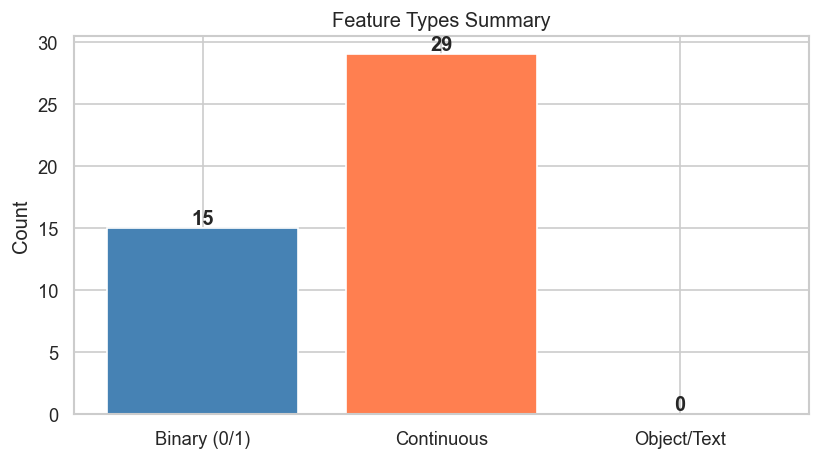

In [22]:

binary_cols = [c for c in df_clean.columns
               if df_clean[c].nunique() == 2 and
               set(df_clean[c].unique()).issubset({0,1,0.0,1.0})]

print(f"Binary (0/1) columns found: {len(binary_cols)}")
print(binary_cols)


cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"\nObject/String columns: {cat_cols}")
print("→ No encoding needed (all categoricals already binary-encoded)")

fig, ax = plt.subplots(figsize=(7, 4))
type_counts = {'Binary (0/1)': len(binary_cols),
               'Continuous': len(numeric_cols) - len(binary_cols),
               'Object/Text': len(cat_cols)}
ax.bar(type_counts.keys(), type_counts.values(),
       color=['steelblue','coral','gray'], edgecolor='white')
ax.set_title('Feature Types Summary')
ax.set_ylabel('Count')
for i, (k, v) in enumerate(type_counts.items()):
    ax.text(i, v+0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Save Clean Data

In [23]:
import os
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)


save_df = df_clean.drop(columns=['polarity_bin'], errors='ignore')

save_df.to_csv('data/clean_data.csv', index=False)

print(" Clean data saved → data/clean_data.csv")
print(f"Final shape: {save_df.shape}")
print(f"\nColumns saved: {save_df.shape[1]}")
print(f"Rows saved:    {save_df.shape[0]:,}")
print(f"\nTarget columns included:")
print(f"  - shares:      ")
print(f"  - log_shares:  ")
print(f"  - popular:     ")

 Clean data saved → data/clean_data.csv
Final shape: (38462, 61)

Columns saved: 61
Rows saved:    38,462

Target columns included:
  - shares:      
  - log_shares:  
  - popular:     
